# How to open result

This tutorial demonstrates how to open and review results using workflow method.

## Prerequisites

### Perform imports

In [1]:
import os
from pathlib import Path

from ansys.speos.core import Project, Speos, launcher
from ansys.speos.core.generic.version_checker import server_version_checker
from ansys.speos.core.kernel.client import (
    default_docker_channel,
)
from ansys.speos.core.simulation import SimulationDirect


### Define constants
Constants help ensure consistency and avoid repetition throughout the example.

In [2]:
HOSTNAME = "localhost"
GRPC_PORT = 50098  # Be sure the Speos GRPC Server has been started on this port.
FILE_NAME = "LG_50M_Colorimetric_short.sv5"
RESULT_NAME = "ASSEMBLY1.DS (0).Dom Irradiance Sensor (0).xmp"
USE_DOCKER = True  # Set to False if you're running this example locally as a Notebook.
USE_GPU = False

## Model Setup

### Load assets
The assets used to run this example are available in the
[PySpeos repository](https://github.com/ansys/pyspeos/) on GitHub.

> **Note:** Make sure you
> have downloaded simulation assets and set ``assets_data_path``
> to point to the assets folder.

In [3]:
if USE_DOCKER:  # Running on the remote server.
    assets_data_path = Path("/app") / "assets"
else:
    assets_data_path = Path("/path/to/your/download/assets/directory")

### Connect to the RPC Server
This Python client connects to a server where the Speos engine
is running as a service. In this example, the server and
client are the same
machine.

In [4]:
if USE_DOCKER:
    speos = Speos(channel=default_docker_channel())
else:
    speos = launcher.launch_local_speos_rpc_server(port=GRPC_PORT)

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/common/cyberchannel.py:201: UserWarning: Starting gRPC client without TLS on localhost:50098. This is INSECURE. Consider using a secure connection.
  warn(f"Starting gRPC client without TLS on {target}. This is INSECURE. Consider using a secure connection.")


### Create project from a Speos file

The ``Project`` class is instantiated by passing a ``Speos`` instance and the name of the Speos
project file.

In [5]:
p = Project(
    speos=speos,
    path=str(assets_data_path / FILE_NAME / FILE_NAME),
)
print(p)

{
    "name": "LG_50M_Colorimetric_short",
    "description": "From Speos file: /app/assets/LG_50M_Colorimetric_short.sv5/LG_50M_Colorimetric_short.sv5",
    "part_guid": "99549781-9cf8-4882-b858-67e5d52ae205",
    "sources": [
        {
            "name": "Dom Source 2 (0) in SOURCE2",
            "metadata": {
                "UniqueId": "ca1154b4-4bfb-4b02-8dd9-12a398a4ad47"
            },
            "source_guid": "c82e983f-6696-4619-bc59-ebc86ecb51cb",
            "display_name": "",
            "description": "",
            "source": {
                "name": "Dom Source 2 (0) in SOURCE2",
                "surface": {
                    "radiant_flux": {
                        "radiant_value": 6.590041607465698
                    },
                    "intensity_guid": "64bbf017-e803-46b1-888d-5ae2823dc69e",
                    "exitance_constant": {
                        "geo_paths": [
                            {
                                "geo_path": "Solid Body

### Retrieve the simulation feature

Use the method ``Project.find()`` to retrieve an instance
of the ``SimulationDirect`` feature.

In [6]:
sim = p.find(name=".*", name_regex=True, feature_type=SimulationDirect)[0]

## Run simulation

The simulation can be run using either the CPU or with GPU acceleration. The following cell shows
how Python is used to assign the appropriate method to ``run_sim``.

In [7]:
run_sim = sim.compute_GPU if USE_GPU else sim.compute_CPU
results = run_sim()  # run the simulation
print(results)

[upload_response {
  info {
    uri: "7945ffe2-cb55-4284-96bc-58e963d8a716"
    file_name: "ASSEMBLY1.DS (0).Dom Irradiance Sensor (0).xmp"
    file_size: 1802680
  }
}
, upload_response {
  info {
    uri: "0f52e85f-8cad-4ecf-a27d-79f66e0c9f97"
    file_name: "ASSEMBLY1.DS (0).html"
    file_size: 250826
  }
}
]


## Postprocessing
### Open the results:

Display one result as image.

A full path can be given, or the name of the result.

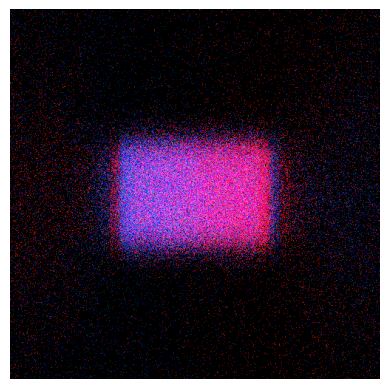

In [8]:
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name=RESULT_NAME)

### Display the image

Display one result in a result viewer.

A full path can be given, or the name of the result.

In [9]:
if os.name == "nt":
    from ansys.speos.core.workflow.open_result import open_result_in_viewer

    open_result_in_viewer(
        simulation_feature=sim,
        result_name=RESULT_NAME,
    )

### Export the XMP result to PNG image

Export one result to a PNG image file.

A full path can be given, or the name of the result.

In [10]:
from ansys.speos.core.workflow.open_result import export_xmp_to_image

In [11]:
exported_image = export_xmp_to_image(simulation_feature=sim, result_name=RESULT_NAME)
if exported_image.HasField("path"):
    print(exported_image.path)  # Local path of the exported image on the server.
elif exported_image.HasField("upload_response"):
    print(
        exported_image.upload_response.info.uri
    )  # URI of the exported image on the server, which can be used to download the file.

623817af-ceef-4679-8b0d-bb2ae2c30d26


In [12]:
speos.close()

True